In [1]:
import pandas as pd
import lightgbm as lgb
from dataclasses import dataclass
from pathlib import Path
from matplotlib.axes import Axes
from matplotlib.dates import DateFormatter
import numpy as np

from freeze_thaw.config import config as c, StationName
from freeze_thaw.data_preparation.splitting import get_test_set
from freeze_thaw.modeling.lgb_test import lgb_pred, TestResult
from freeze_thaw.evaluation.metrics import formatted_cm, calculate_f1_scores
from freeze_thaw.data_understanding.visualization import plot_with_labels
from freeze_thaw.evaluation.statistics import paired_permutation_test

# LightGBM Model Trained on ASCAT Data vs ERA5

This notebook will determine if there's any difference in using a lightGBM model with default parameters trained on ASCAT data vs ERA5 in predicting the soil state at individual ISMN stations. The two methods will be evaluated on 20% of the data (most recent). First, confusion matrices will be compared between the two methods for each station. Then, a statistical analysis will be done to determine if there's a statistically significant difference in the two methods when it comes to the macro and transition F1 scores.

---

## Table of Contents

1. **Setup**
    - *1.1 Variables*
    - *1.2 Functions*
2. **ISMN Stations**
    - *2.1 Aberdeen-35-WNW*
    - *2.2 Jamestown-38-WSW*
    - *2.3 Gobblers Knob*
    - *2.4 Nenana*
    - *2.5 L23*
    - *2.6 L38*
    - *2.7 NST-07*
    - *2.8 NST-09*
    - *2.9 SOD012*
    - *2.10 SOD103*
3. **F1 Scores**
4. **Statistical Analysis**
5. **Conclusions**
---

## 1. Setup

### 1.1 Variables

In [2]:
result_df_ascat = pd.DataFrame(columns=["Station", "Macro F1", "Transition F1"])
result_df_era5 = pd.DataFrame(columns=["Station", "Macro F1", "Transition F1"])

label_map = {
    c.CLASSES[0]: 0,
    c.CLASSES[1]: 1,
    c.CLASSES[2]: 2,
}
train_size = 0.8

lagged_features = True
lags_optimal = [1, 2]

### 1.2 Functions

In [3]:
@dataclass(frozen=True)
class ERA5Results:
    macro_f1: float
    transition_f1: float
    y_pred: pd.Series

@dataclass(frozen=True)
class StationResults:
    y_true: pd.Series
    ismn_data: pd.DataFrame
    lgb_results: TestResult
    era5_results: ERA5Results

def process_one_station(station: StationName,
                        train_size: float,
                        label_map: dict[str, int],
                        model_dir: Path | None = None,
                        ismn_long_var_name: str | None = None) -> StationResults:
    """
    For the given station, load lgb model, predict on test set, and return model results and ERA5 predictions.
    :param station: name of the ISMN station
    :param train_size: decimal fraction size of training data
    :param label_map: mapping of class names to int labels
    :param model_dir: path to directory containing the models
    :param ismn_long_var_name: long name of the ISMN key variable
    :return: StationResults
    """
    model_dir = model_dir or c.MODEL_PATH
    ismn_long_var_name = ismn_long_var_name or c.ISMN_LONG_VAR_NAME

    ascat_test, era5_test = get_test_set(station,
                                         train_size=train_size,
                                         label_map=label_map,
                                         lagged_features=lagged_features,
                                         lags=lags_optimal)
    y_true = era5_test["class"]

    lgb_model = lgb.Booster(model_file=model_dir / f"{station}_rolling_model.txt")
    lgb_results = lgb_pred(ascat_test, lgb_model, label_map)

    era5_macro_f1, era5_transition_f1 = calculate_f1_scores(y_true, era5_test["pred"], list(label_map.keys()))

    era5_results = ERA5Results(macro_f1=era5_macro_f1,
                               transition_f1=era5_transition_f1,
                               y_pred=era5_test["pred"])

    ismn_data = era5_test.copy()
    ismn_data = ismn_data.drop(columns=[col for col in ismn_data.columns if col != ismn_long_var_name])

    return StationResults(y_true=y_true,
                          lgb_results=lgb_results,
                          era5_results=era5_results,
                          ismn_data=ismn_data)

def create_plot_df(ismn_data: pd.DataFrame,
                   lgb_pred: np.ndarray,
                   era5_pred: pd.Series) -> pd.DataFrame:
    """
    Prepare plot df needed as input for plot_predictions().
    :param ismn_data: pd.DataFrame from StationResults.ismn_data
    :param lgb_pred: np.ndarray from TestResult
    :param era5_pred: pd.Series from ERA5Results
    :return: pd.DataFrame
    """
    plot_df = ismn_data.copy()
    plot_df["lgb_pred"] = lgb_pred
    plot_df["era5_pred"] = era5_pred

    return plot_df

def plot_predictions(df: pd.DataFrame,
                     station: StationName,
                     method: str,
                     *,
                     ismn_long_var_name: str | None = None,
                     class_boundary: float | None = None) -> Axes:
    """
    Plot predictions for a given station and method. Assumed that class boundary is symmetric across the zero temperature line.
    :param df: must have a datetime index and  contain the following columns: ("lgb_pred" or "era5_pred") and ismn_long_var_name.
    :param station: name of the ISMN station
    :param method: "lgb_pred" or "era5_pred"
    :param ismn_long_var_name: long variable name for ISMN soil temperature
    :param class_boundary: symmetric temperature boundary (°C) around the freezing point
    :return: Axes object
    """
    ismn_long_var_name = ismn_long_var_name or c.ISMN_LONG_VAR_NAME
    class_boundary = class_boundary or c.CLASS_BOUNDARY

    if method not in ("lgb_pred", "era5_pred"):
        raise ValueError("method must be 'lgb_pred' or 'era5_pred'")
    if not {method, ismn_long_var_name}.issubset(df.columns):
        raise ValueError(f"df must have columns: '{method}' and '{ismn_long_var_name}'. It currently only has {df.columns}")

    axes = plot_with_labels(df,
                            ismn_long_var_name,
                            hue=method)

    title_fragment = "LightGBM Model"
    if method == "era5_pred":
        title_fragment = "ERA5 Model"
    axes.set_title(f"{title_fragment} Predictions for {station}")

    # remove the legend title
    legend = axes.legend()
    legend.set_title("")

    # rotate x-ticks
    xticks = axes.get_xticks()
    axes.set_xticks(xticks) # to avoid warning
    axes.set_xticklabels(axes.get_xticklabels(), rotation=45)

    # set the x-axis date format to YYYY-MM
    date_format = DateFormatter('%Y-%m')
    axes.xaxis.set_major_formatter(date_format)

    axes.set_xlabel("Timestamp")

    axes.set_ylabel("ISMN Soil Temperature (\u00B0C)")

    return axes

## 2. ISMN Stations

### 2.1 Aberdeen-35-WNW

In [4]:
aberdeen_results = process_one_station(StationName.ABERDEEN, train_size=train_size, label_map=label_map)

result_df_ascat.loc[len(result_df_ascat)] = [StationName.ABERDEEN,
                                             aberdeen_results.lgb_results.macro_f1,
                                             aberdeen_results.lgb_results.transition_f1]
result_df_era5.loc[len(result_df_era5)] = [StationName.ABERDEEN,
                                           aberdeen_results.era5_results.macro_f1,
                                           aberdeen_results.era5_results.transition_f1]

aberdeen_plot_df = create_plot_df(aberdeen_results.ismn_data,
                                  aberdeen_results.lgb_results.y_pred,
                                  aberdeen_results.era5_results.y_pred)

#### LightGBM Model

In [5]:
formatted_cm(aberdeen_results.y_true, aberdeen_results.lgb_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,546,36,85
transition,76,27,103
thawed,57,6,2121


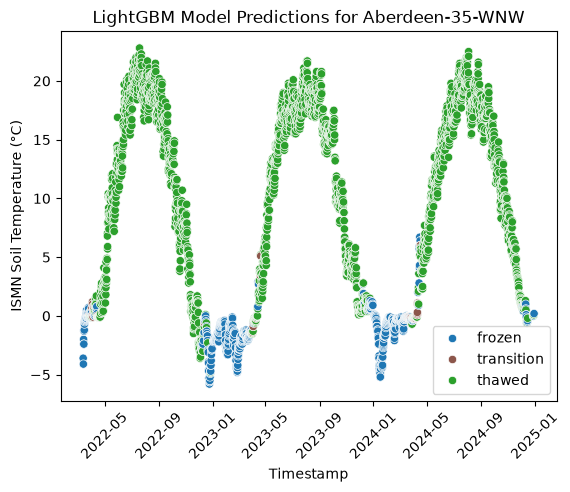

In [6]:
axes = plot_predictions(aberdeen_plot_df, StationName.ABERDEEN, method="lgb_pred")

#### ERA5

In [7]:
formatted_cm(aberdeen_results.y_true, aberdeen_results.era5_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,514,106,47
transition,79,37,90
thawed,156,86,1942


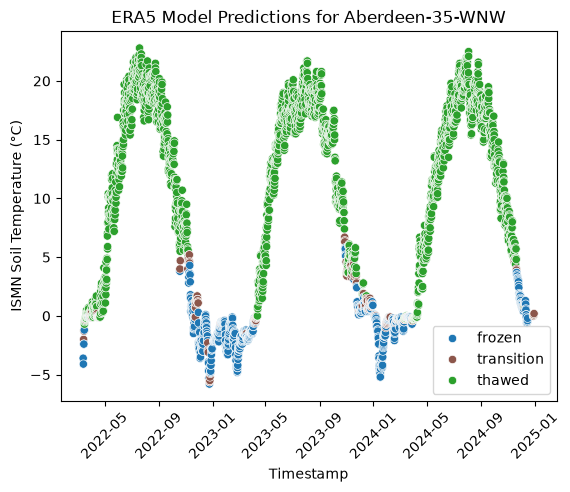

In [8]:
axes = plot_predictions(aberdeen_plot_df, StationName.ABERDEEN, method="era5_pred")

The lightGBM model outperformed in predicting the frozen and thawed states but traded this for inaccurate predictions for the transition state.

### 2.2 Jamestown-38-WSW

In [9]:
jamestown_results = process_one_station(StationName.JAMESTOWN, train_size=train_size, label_map=label_map)

result_df_ascat.loc[len(result_df_ascat)] = [StationName.JAMESTOWN,
                                             jamestown_results.lgb_results.macro_f1,
                                             jamestown_results.lgb_results.transition_f1]
result_df_era5.loc[len(result_df_era5)] = [StationName.JAMESTOWN,
                                           jamestown_results.era5_results.macro_f1,
                                           jamestown_results.era5_results.transition_f1]

jamestown_plot_df = create_plot_df(jamestown_results.ismn_data,
                                   jamestown_results.lgb_results.y_pred,
                                   jamestown_results.era5_results.y_pred)

#### LightGBM Model

In [10]:
formatted_cm(jamestown_results.y_true, jamestown_results.lgb_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,777,12,61
transition,69,1,82
thawed,57,10,1936


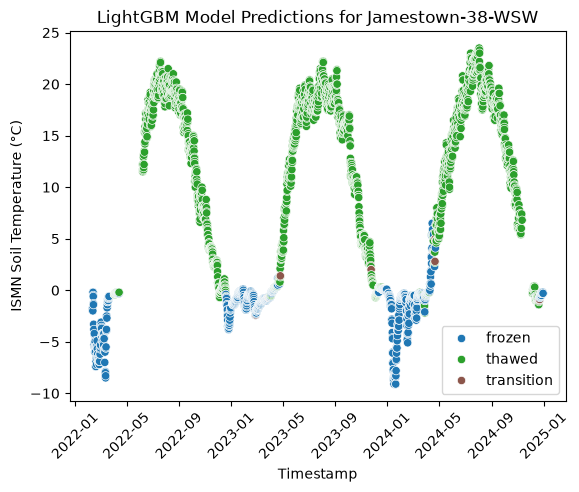

In [11]:
axes = plot_predictions(jamestown_plot_df, StationName.JAMESTOWN, method="lgb_pred")

#### ERA5

In [12]:
formatted_cm(jamestown_results.y_true, jamestown_results.era5_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,681,94,75
transition,103,27,22
thawed,128,97,1778


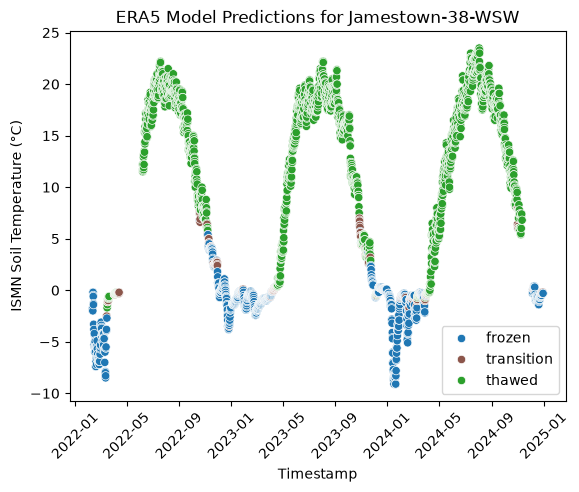

In [13]:
axes = plot_predictions(jamestown_plot_df, StationName.JAMESTOWN, method="era5_pred")

Similar trends as in Aberdeen but with even worse performance on the transition state for the lightGBM model.

### 2.3 Gobblers Knob

In [14]:
gobblers_knob_results = process_one_station(StationName.GOBBLERS_KNOB, train_size=train_size, label_map=label_map)

result_df_ascat.loc[len(result_df_ascat)] = [StationName.GOBBLERS_KNOB,
                                             gobblers_knob_results.lgb_results.macro_f1,
                                             gobblers_knob_results.lgb_results.transition_f1]
result_df_era5.loc[len(result_df_era5)] = [StationName.GOBBLERS_KNOB,
                                           gobblers_knob_results.era5_results.macro_f1,
                                           gobblers_knob_results.era5_results.transition_f1]

gobblers_knob_plot_df = create_plot_df(gobblers_knob_results.ismn_data,
                                       gobblers_knob_results.lgb_results.y_pred,
                                       gobblers_knob_results.era5_results.y_pred)

#### LightGBM Model

In [15]:
formatted_cm(gobblers_knob_results.y_true, gobblers_knob_results.lgb_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,3813,46,98
transition,99,54,178
thawed,1,5,1726


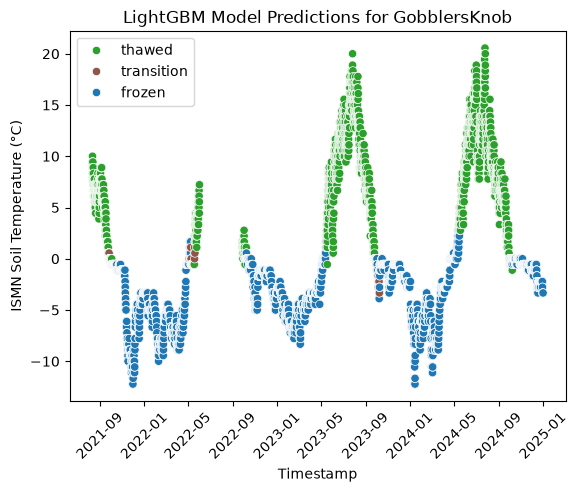

In [16]:
axes = plot_predictions(gobblers_knob_plot_df, StationName.GOBBLERS_KNOB, method="lgb_pred")

#### ERA5

In [17]:
formatted_cm(gobblers_knob_results.y_true, gobblers_knob_results.era5_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,2936,994,27
transition,53,147,131
thawed,29,21,1682


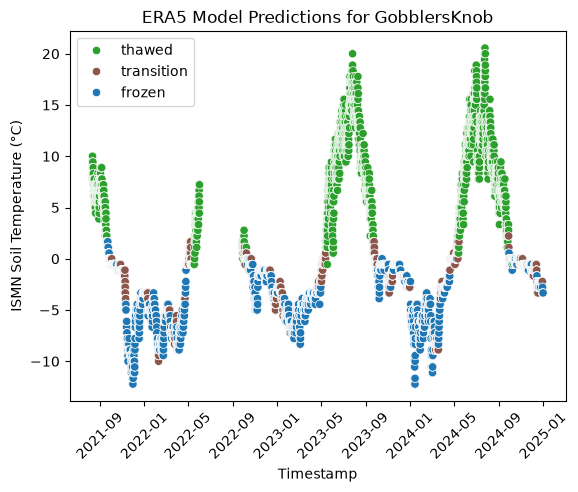

In [18]:
axes = plot_predictions(gobblers_knob_plot_df, StationName.GOBBLERS_KNOB, method="era5_pred")

The lightGBM model outperformed significantly in predicting the frozen state and to a lesser degree for the thawed state. But the predictions were worse for the transition state.

### 2.4 Nenana

In [19]:
nenana_results = process_one_station(StationName.NENANA, train_size=train_size, label_map=label_map)

result_df_ascat.loc[len(result_df_ascat)] = [StationName.NENANA,
                                             nenana_results.lgb_results.macro_f1,
                                             nenana_results.lgb_results.transition_f1]
result_df_era5.loc[len(result_df_era5)] = [StationName.NENANA,
                                           nenana_results.era5_results.macro_f1,
                                           nenana_results.era5_results.transition_f1]

nenana_plot_df = create_plot_df(nenana_results.ismn_data,
                                nenana_results.lgb_results.y_pred,
                                nenana_results.era5_results.y_pred)

#### LightGBM Model

In [20]:
formatted_cm(nenana_results.y_true, nenana_results.lgb_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,2246,80,27
transition,30,23,94
thawed,42,17,1541


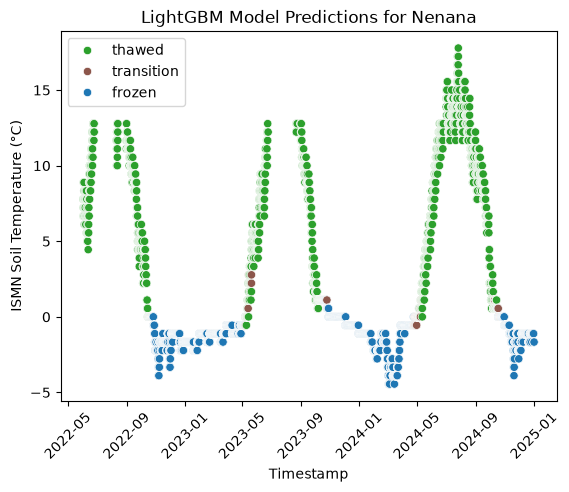

In [21]:
axes = plot_predictions(nenana_plot_df, StationName.NENANA, method="lgb_pred")

#### ERA5

In [22]:
formatted_cm(nenana_results.y_true, nenana_results.era5_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,1951,286,116
transition,44,2,101
thawed,138,84,1378


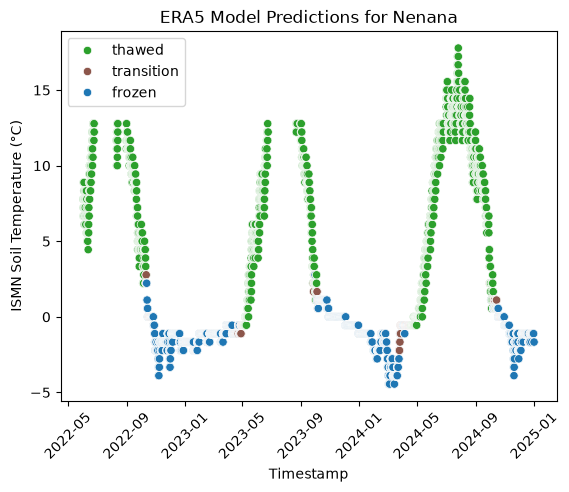

In [23]:
axes = plot_predictions(nenana_plot_df, StationName.NENANA, method="era5_pred")

The lightGBM model outperformed across the board.

### 2.5 L23

In [24]:
l23_results = process_one_station(StationName.L23, train_size=train_size, label_map=label_map)

result_df_ascat.loc[len(result_df_ascat)] = [StationName.L23,
                                             l23_results.lgb_results.macro_f1,
                                             l23_results.lgb_results.transition_f1]
result_df_era5.loc[len(result_df_era5)] = [StationName.L23,
                                           l23_results.era5_results.macro_f1,
                                           l23_results.era5_results.transition_f1]

l23_plot_df = create_plot_df(l23_results.ismn_data,
                             l23_results.lgb_results.y_pred,
                             l23_results.era5_results.y_pred)

#### LightGBM Model

In [25]:
formatted_cm(l23_results.y_true, l23_results.lgb_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,114,0,0
transition,139,110,102
thawed,0,0,323


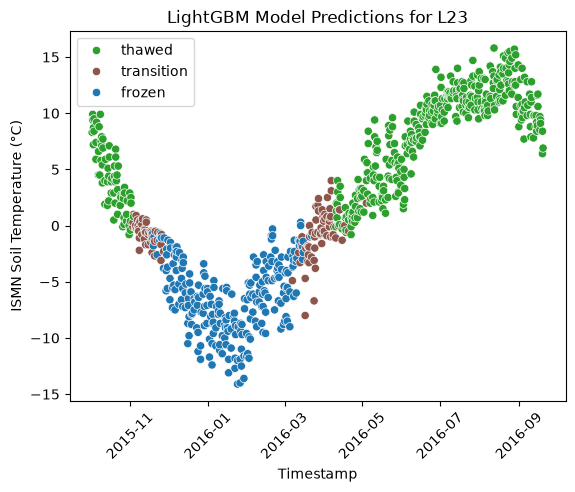

In [26]:
axes = plot_predictions(l23_plot_df, StationName.L23, method="lgb_pred")

#### ERA5

In [27]:
formatted_cm(l23_results.y_true, l23_results.era5_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,114,0,0
transition,323,28,0
thawed,2,25,296


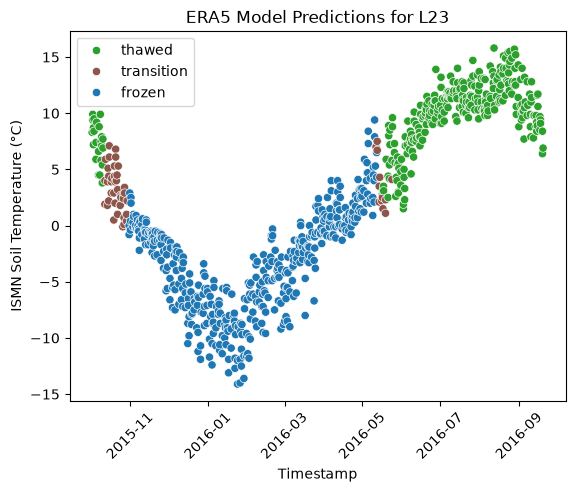

In [28]:
axes = plot_predictions(l23_plot_df, StationName.L23, method="era5_pred")

The lightGBM model outperformed across the board.

### 2.6 L38

In [29]:
l38_results = process_one_station(StationName.L38, train_size=train_size, label_map=label_map)

result_df_ascat.loc[len(result_df_ascat)] = [StationName.L38,
                                             l38_results.lgb_results.macro_f1,
                                             l38_results.lgb_results.transition_f1]
result_df_era5.loc[len(result_df_era5)] = [StationName.L38,
                                           l38_results.era5_results.macro_f1,
                                           l38_results.era5_results.transition_f1]

l38_plot_df = create_plot_df(l38_results.ismn_data,
                             l38_results.lgb_results.y_pred,
                             l38_results.era5_results.y_pred)

#### LightGBM Model

In [30]:
formatted_cm(l38_results.y_true, l38_results.lgb_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,120,6,0
transition,52,135,72
thawed,0,9,392


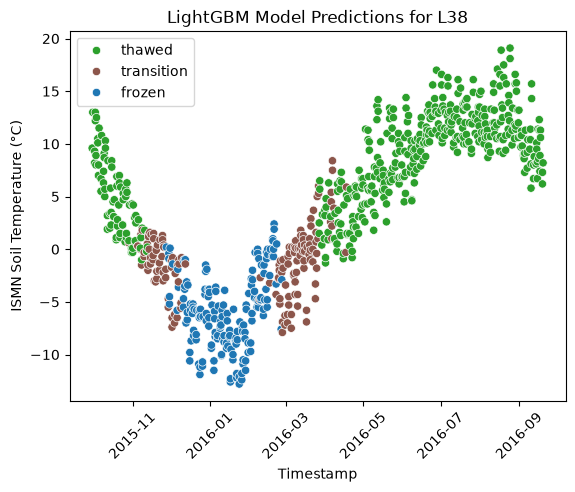

In [31]:
axes = plot_predictions(l38_plot_df, StationName.L38, method="lgb_pred")

#### ERA5

In [32]:
formatted_cm(l38_results.y_true, l38_results.era5_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,126,0,0
transition,245,14,0
thawed,23,61,317


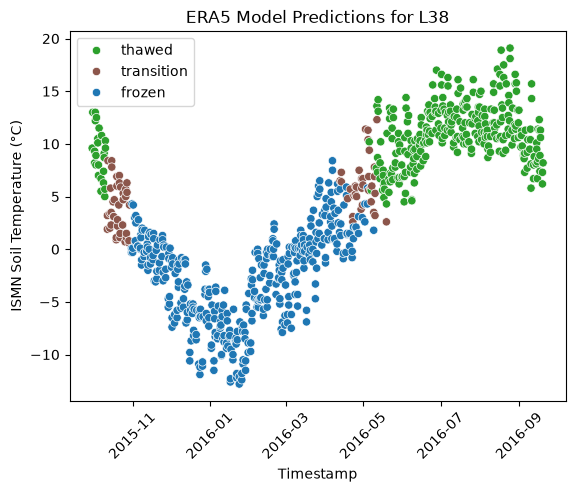

In [33]:
axes = plot_predictions(l38_plot_df, StationName.L38, method="era5_pred")

The lightGBM model outperformed significantly when it came to the transition and thawed states. It was marginally worse in predicting the frozen state.

### 2.7 NST-07

In [34]:
nst07_results = process_one_station(StationName.NST_07, train_size=train_size, label_map=label_map)

result_df_ascat.loc[len(result_df_ascat)] = [StationName.NST_07,
                                             nst07_results.lgb_results.macro_f1,
                                             nst07_results.lgb_results.transition_f1]
result_df_era5.loc[len(result_df_era5)] = [StationName.NST_07,
                                           nst07_results.era5_results.macro_f1,
                                           nst07_results.era5_results.transition_f1]

nst07_plot_df = create_plot_df(nst07_results.ismn_data,
                             nst07_results.lgb_results.y_pred,
                             nst07_results.era5_results.y_pred)

#### LightGBM Model

In [35]:
formatted_cm(nst07_results.y_true, nst07_results.lgb_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,150,18,0
transition,55,85,21
thawed,12,74,683


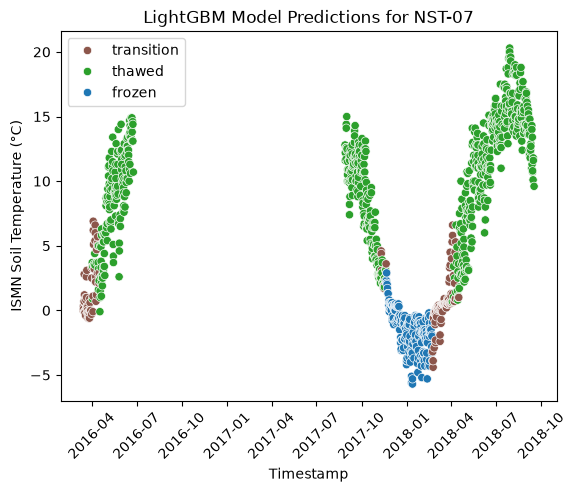

In [36]:
axes = plot_predictions(nst07_plot_df, StationName.NST_07, method="lgb_pred")

#### ERA5

In [37]:
formatted_cm(nst07_results.y_true, nst07_results.era5_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,168,0,0
transition,89,51,21
thawed,36,88,645


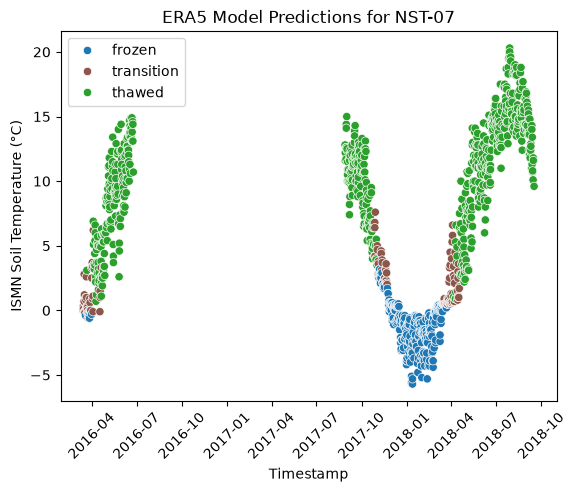

In [38]:
axes = plot_predictions(nst07_plot_df, StationName.NST_07, method="era5_pred")

The lightGBM model outperformed with the transition and thawed states while doing worse with the frozen state.

### 2.8 NST-09

In [39]:
nst09_results = process_one_station(StationName.NST_09, train_size=train_size, label_map=label_map)

result_df_ascat.loc[len(result_df_ascat)] = [StationName.NST_09,
                                             nst09_results.lgb_results.macro_f1,
                                             nst09_results.lgb_results.transition_f1]
result_df_era5.loc[len(result_df_era5)] = [StationName.NST_09,
                                           nst09_results.era5_results.macro_f1,
                                           nst09_results.era5_results.transition_f1]

nst09_plot_df = create_plot_df(nst09_results.ismn_data,
                             nst09_results.lgb_results.y_pred,
                             nst09_results.era5_results.y_pred)

#### LightGBM Model

In [40]:
formatted_cm(nst09_results.y_true, nst09_results.lgb_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,172,29,0
transition,101,120,17
thawed,0,18,689


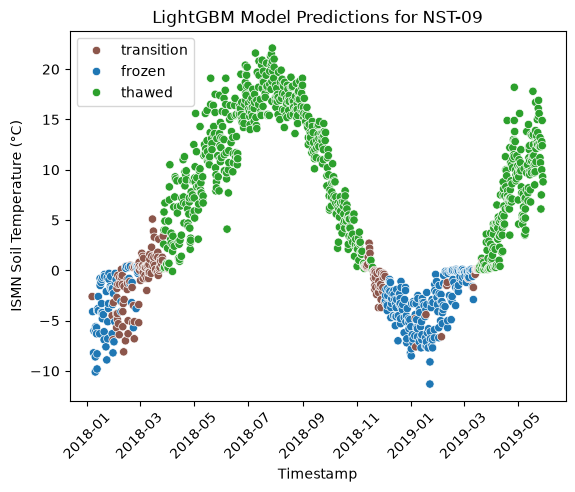

In [41]:
axes = plot_predictions(nst09_plot_df, StationName.NST_09, method="lgb_pred")

#### ERA5

In [42]:
formatted_cm(nst09_results.y_true, nst09_results.era5_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,201,0,0
transition,197,38,3
thawed,80,64,563


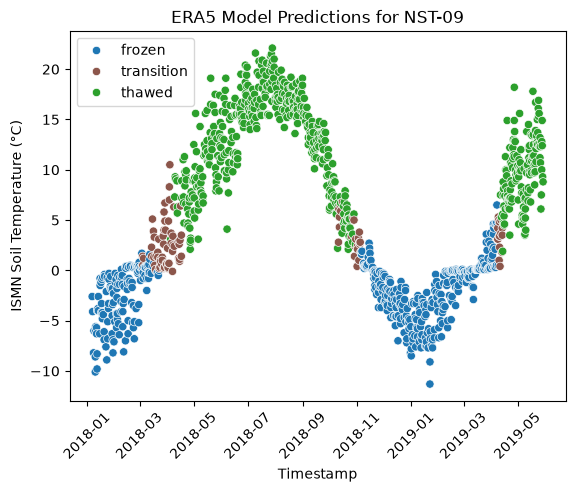

In [43]:
axes = plot_predictions(nst09_plot_df, StationName.NST_09, method="era5_pred")

The lightGBM model outperformed with the transition and thawed states while doing worse with the frozen state.

### 2.9 SOD012

In [44]:
sod012_results = process_one_station(StationName.SOD012, train_size=train_size, label_map=label_map)

result_df_ascat.loc[len(result_df_ascat)] = [StationName.SOD012,
                                             sod012_results.lgb_results.macro_f1,
                                             sod012_results.lgb_results.transition_f1]
result_df_era5.loc[len(result_df_era5)] = [StationName.SOD012,
                                           sod012_results.era5_results.macro_f1,
                                           sod012_results.era5_results.transition_f1]

sod012_plot_df = create_plot_df(sod012_results.ismn_data,
                                sod012_results.lgb_results.y_pred,
                                sod012_results.era5_results.y_pred)

#### LightGBM Model

In [45]:
formatted_cm(sod012_results.y_true, sod012_results.lgb_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,784,17,381
transition,211,24,201
thawed,343,77,3283


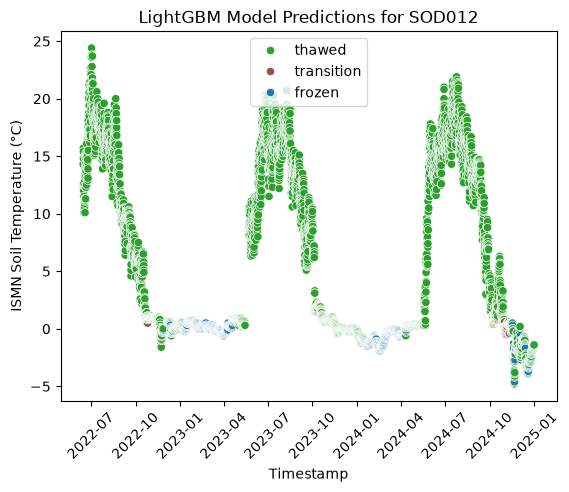

In [46]:
axes = plot_predictions(sod012_plot_df, StationName.SOD012, method="lgb_pred")

#### ERA5

In [47]:
formatted_cm(sod012_results.y_true, sod012_results.era5_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,1042,140,0
transition,371,58,7
thawed,780,509,2414


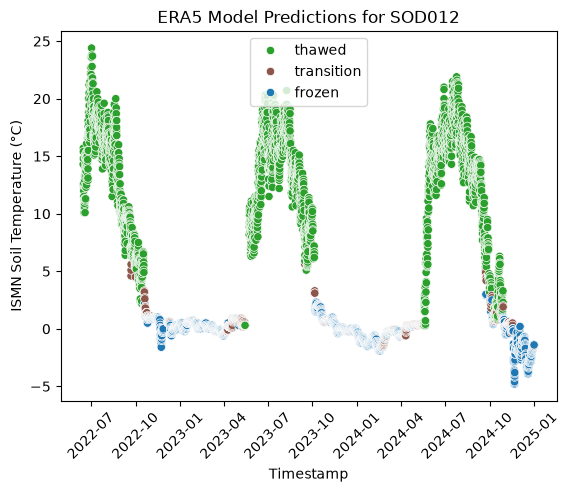

In [48]:
axes = plot_predictions(sod012_plot_df, StationName.SOD012, method="era5_pred")

The lightGBM model performed quite poorly except for the thawed class.

### 2.10 SOD103

In [49]:
sod103_results = process_one_station(StationName.SOD103, train_size=train_size, label_map=label_map)

result_df_ascat.loc[len(result_df_ascat)] = [StationName.SOD103,
                                             sod103_results.lgb_results.macro_f1,
                                             sod103_results.lgb_results.transition_f1]
result_df_era5.loc[len(result_df_era5)] = [StationName.SOD103,
                                           sod103_results.era5_results.macro_f1,
                                           sod103_results.era5_results.transition_f1]

sod103_plot_df = create_plot_df(sod103_results.ismn_data,
                                sod103_results.lgb_results.y_pred,
                                sod103_results.era5_results.y_pred)

#### LightGBM Model

In [50]:
formatted_cm(sod103_results.y_true, sod103_results.lgb_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,0,10,53
transition,42,34,240
thawed,226,206,4401


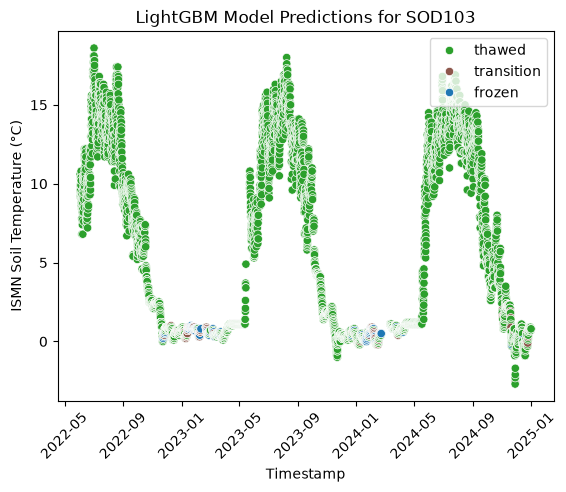

In [51]:
axes = plot_predictions(sod103_plot_df, StationName.SOD103, method="lgb_pred")

#### ERA5

In [52]:
formatted_cm(sod103_results.y_true, sod103_results.era5_results.y_pred, c.CLASSES)

,frozen,transition,thawed
frozen,63,0,0
transition,316,0,0
thawed,1704,673,2456


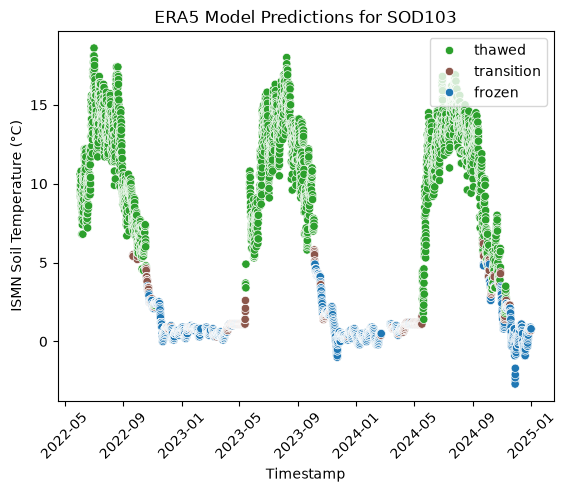

In [53]:
axes = plot_predictions(sod103_plot_df, StationName.SOD103, method="era5_pred")

The test set for this station was unusual since there were only a handle of observations that were classified as frozen. The lightGBM model significantly outperformed for the transition and thawed states.

## 3. F1 Scores

#### LightGBM

In [54]:
result_df_ascat

,Station,Macro F1,Transition F1
0,Aberdeen-35-WNW,0.650597,0.196364
1,Jamestown-38-WSW,0.615488,0.011429
2,GobblersKnob,0.713727,0.247706
3,Nenana,0.692927,0.172285
4,L23,0.654038,0.477223
5,L38,0.790625,0.660147
6,NST-07,0.736513,0.502959
7,NST-09,0.764520,0.592593
8,SOD012,0.525488,0.086643
9,SOD103,0.348014,0.120141


#### ERA5

In [55]:
result_df_era5

,Station,Macro F1,Transition F1
0,Aberdeen-35-WNW,0.602400,0.170115
1,Jamestown-38-WSW,0.611966,0.145946
2,GobblersKnob,0.660184,0.196919
3,Nenana,0.580041,0.007707
4,L23,0.502431,0.138614
5,L38,0.483819,0.083832
6,NST-07,0.655935,0.340000
7,NST-09,0.566700,0.223529
8,SOD012,0.502447,0.101487
9,SOD103,0.244202,0.000000


#### Difference in Scores

Show the scores for lgb - ERA5, with positive scores indicating better performance by the lightGBM model.

In [56]:
score_diffs = result_df_ascat.copy()
float_cols = ["Macro F1", "Transition F1"]
score_diffs[float_cols] = result_df_ascat[float_cols] - result_df_era5[float_cols]
score_diffs = score_diffs.rename(columns={
    "Macro F1": "Macro F1 Difference",
    "Transition F1": "Transition F1 Difference",
})

score_diffs

,Station,Macro F1 Difference,Transition F1 Difference
0,Aberdeen-35-WNW,0.048198,0.026249
1,Jamestown-38-WSW,0.003522,-0.134517
2,GobblersKnob,0.053543,0.050787
3,Nenana,0.112887,0.164578
4,L23,0.151607,0.338610
5,L38,0.306806,0.576314
6,NST-07,0.080578,0.162959
7,NST-09,0.197820,0.369063
8,SOD012,0.023041,-0.014845
9,SOD103,0.103812,0.120141


Overall, the lightGBM model trained on ASCAT data outperformed ERA5.

## 4. Statistical Analysis

Perform a paired sign-flipping permutation test to determine if using there's a statistically significant difference ($\alpha=0.05$) in the F1 scores for the lightGBM model and ERA5.

$H_0: F1_{lgb} = F1_{era5}$

$H_1: F1_{lgb} \neq F1_{era5}$

#### Macro F1

In [59]:
observed_macro_f1, p_value_macro_f1 = paired_permutation_test(result_df_era5["Macro F1"],
                                                              result_df_ascat["Macro F1"],
                                                              alternative="two-sided")

print(f"Observed mean difference: {observed_macro_f1:6f}")
print(f"p-value: {p_value_macro_f1:4f}")

Observed mean difference: 0.108181
p-value: 0.001953


#### Transition F1

In [60]:
observed_transition_f1, p_value_transition_f1 = paired_permutation_test(result_df_era5["Transition F1"],
                                                                        result_df_ascat["Transition F1"],
                                                                        alternative="two-sided")

print(f"Observed mean difference: {observed_transition_f1:6f}")
print(f"p-value: {p_value_transition_f1:4f}")

Observed mean difference: 0.165934
p-value: 0.025391


The calculated p-values for both F1 scores are below $\alpha$ leading to a rejection of the null hypothesis. There's a statistically significant difference in the F1 scores between the lightGBM model and ERA5.